# Chess best move prediction

#### Authors
* Gabriel de Oliveira Pontarolo
* Jennifer Mayara de Paiva Goberski

#### Chess Pieces Dataset
* Roboflow. Chess Pieces Dataset. Roboflow Universe, August 2021. Available at: https://universe.roboflow.com/benjamin-vedlog/chess-full-imvvf. 

### External Dependencies:
* YOLOv11 weights: https://github.com/Gabp0/computer-vision/releases/download/1.0.0/chesspiece-dectection-best-100epc.pt
* Stockfish x86-64 Linux build: https://github.com/official-stockfish/Stockfish/releases/latest/download/stockfish-ubuntu-x86-64.tar

## Import libraries

In [43]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import chess
import chess.svg
import cairosvg
from stockfish import Stockfish

IMG_SRC = "./test_img.jpg"
MODEL_PATH =  "./Data/chesspiece-dectection-best-100epc.pt"
STOCKFISH_PATH = "./Data/stockfish/stockfish-ubuntu-x86-64"

## Detect chesspieces


0: 640x640 2 black-bishops, 1 black-king, 2 black-knights, 8 black-pawns, 1 black-queen, 2 black-rooks, 2 white-bishops, 1 white-king, 2 white-knights, 8 white-pawns, 1 white-queen, 2 white-rooks, 56.3ms
Speed: 4.8ms preprocess, 56.3ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 640)


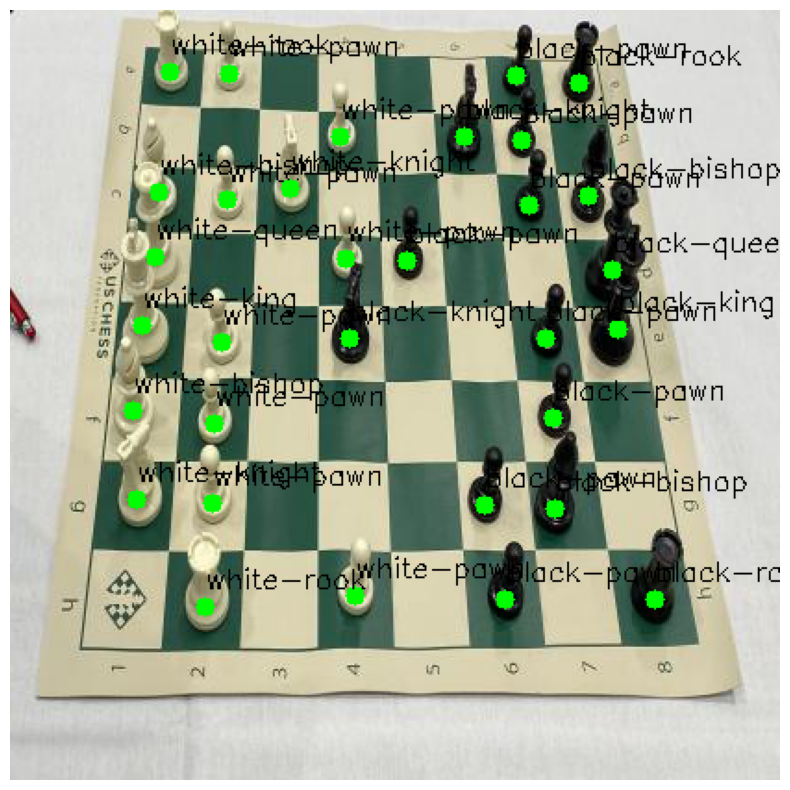

In [44]:
class ChessDetector():
    def __init__(self, model_path):
        self.model = YOLO(model_path)
        self.chess_pieces_names = self.model.names

    def detect(self, image, iou=0.1, conf=0.1):
        results = self.model.predict(source=image, 
                                    augment=True, 
                                    iou=iou, 
                                    conf=conf, 
                                    device='cuda:0')
        chess_pieces = []
        for result in results[0].boxes:
            chess_piece = self.chess_pieces_names[int(result.cls.item())]
            
            # Get bottom center of the bounding box
            x1, y1, x2, y2 = map(int, result.xyxy[0])
            cx = int((x1 + x2) // 2)
            cy = int(y2 - ((y2 - y1) * 0.25))  # Center at the bottom
            
            chess_pieces.append((chess_piece, (cx, cy))) 

        return chess_pieces

def show_image(image):
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

image = cv2.imread(IMG_SRC)
detector = ChessDetector(MODEL_PATH)
detected_pieces = detector.detect(image)

annotated_img = image.copy()
for piece, (cx, cy) in detected_pieces:
    cv2.circle(annotated_img, (cx, cy), 5, (0, 255, 0), -1)
    cv2.putText(annotated_img, piece, (cx, cy - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

show_image(annotated_img)

## Pre-process for contour extraction

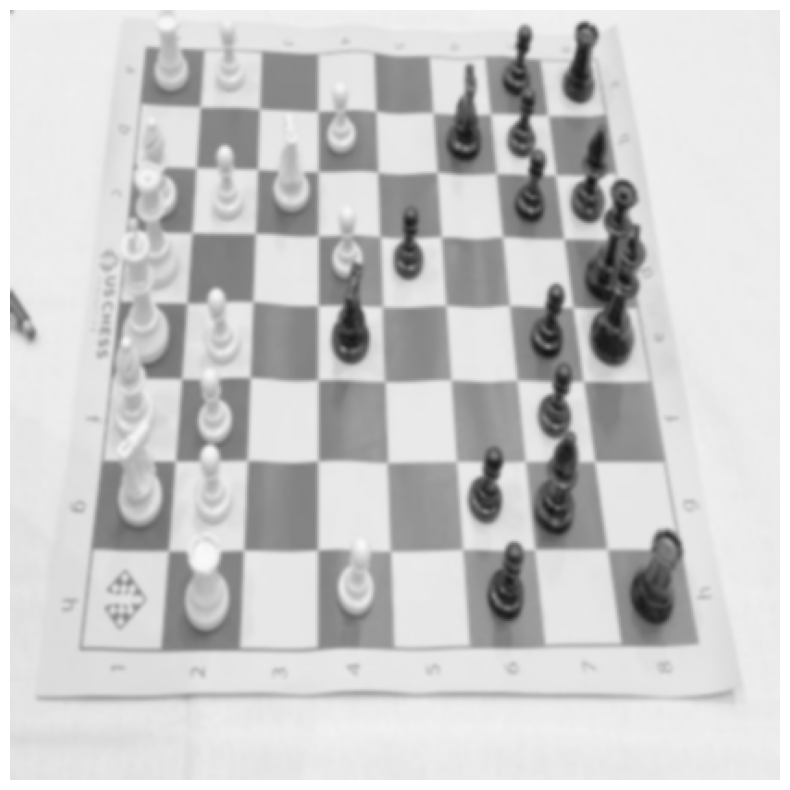

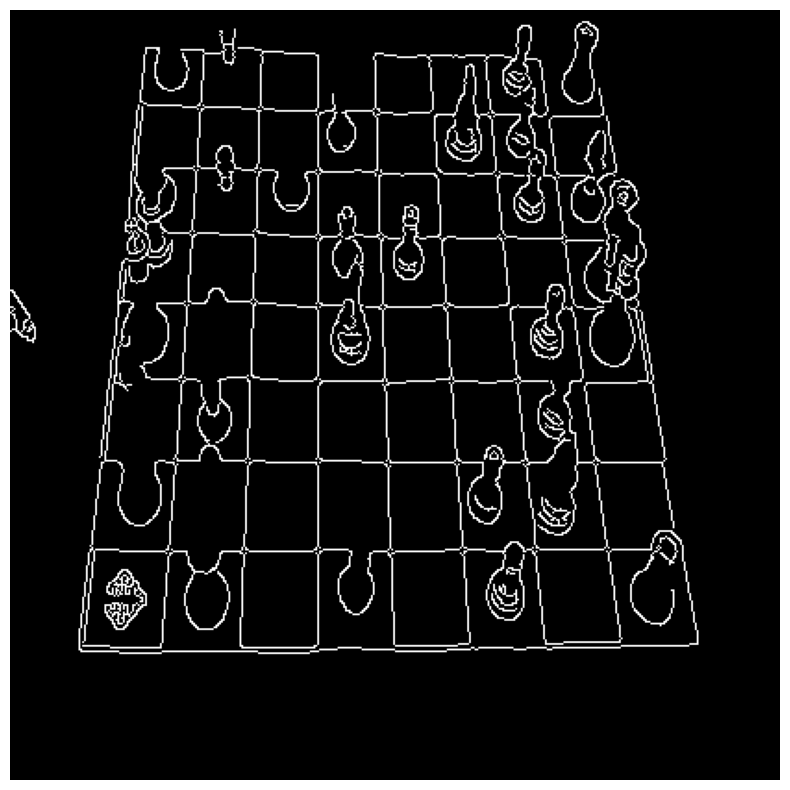

In [45]:
MIN_AREA_RATIO = 0.2        # Minimum area ratio with respect to the image area for contour
POLY_EPISILON_RATIO = 0.1   # Epsilon ratio for contour polygon approximation
CANNY_THRSH = (20, 255)     # Canny edge detection thresholds
GAUSSIAN_KERNEL = (5, 5)    # Gaussian kernel size for noise removal

# Improve contrast using gamma correction
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
lookup_table = np.array([((i / 255.0) ** 0.5) * 255 for i in range(256)], dtype="uint8")
gamma_corrected = cv2.LUT(gray, lookup_table)
preprocessed = cv2.GaussianBlur(gamma_corrected, GAUSSIAN_KERNEL, 0)
show_image(preprocessed)

# Extract edges
edges = cv2.Canny(preprocessed, CANNY_THRSH[0], CANNY_THRSH[1])
dilated = cv2.dilate(edges, None, iterations=2)
show_image(edges)


## Find full board contour

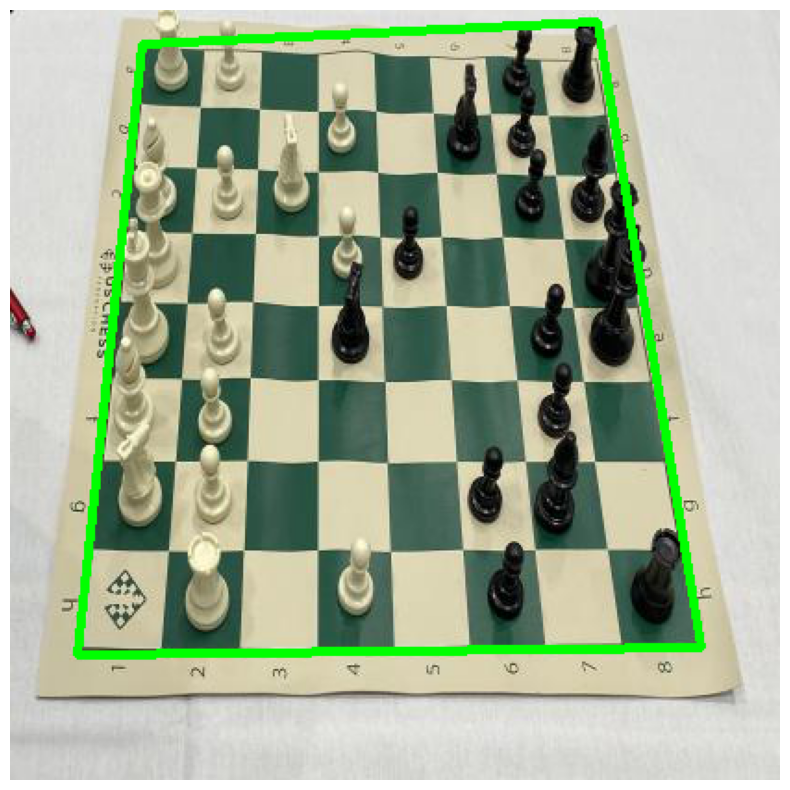

In [46]:
# Find largest square-like contour
board_contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
squares = []
image_area = image.shape[0] * image.shape[1]
for contour in board_contours:
    if cv2.contourArea(contour) < image_area * MIN_AREA_RATIO:
        continue

    poly = cv2.approxPolyDP(contour, POLY_EPISILON_RATIO * cv2.arcLength(contour, True), True)
    if len(poly) == 4:
        squares.append(poly)

# Draw largest square
square = sorted(squares, key=cv2.contourArea, reverse=True)[0]
square_img = cv2.drawContours(image.copy(), [square], -1, (0, 255, 0), 3)
show_image(square_img)

## Warp perspective to focus on board

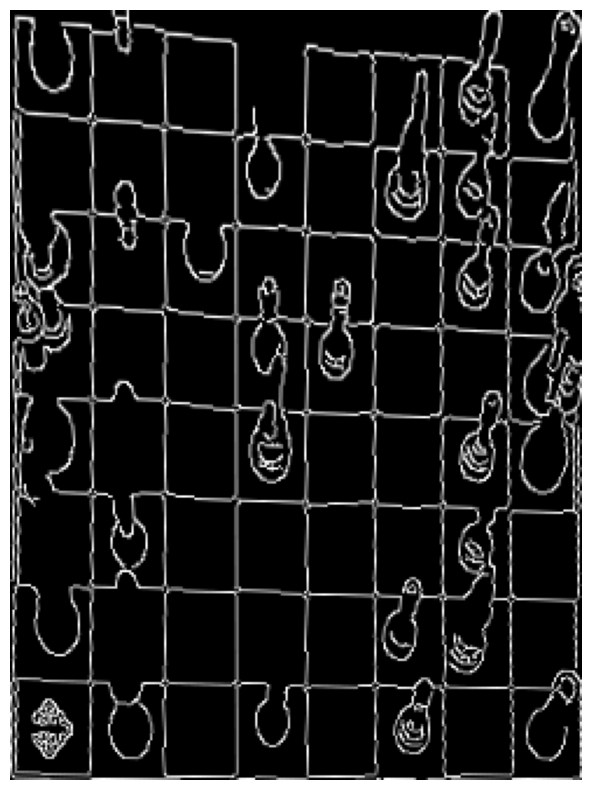

[[     1.0625     0.11269     -77.469]
 [   0.068962      1.4137     -30.343]
 [ 0.00017178     0.00115           1]]


In [47]:
def order_points(points: np.ndarray) -> np.ndarray:
    
    # calculate the sum and difference of the points
    points = points.reshape(4, 2)
    sum_points = points.sum(axis=1)
    diff_points = np.diff(points, axis=1)

    top_right = points[np.argmin(diff_points)]  # point with smallest difference
    top_left = points[np.argmin(sum_points)]    # point with smallest sum
    bottom_left = points[np.argmax(diff_points)] # point with largest difference
    bottom_right = points[np.argmax(sum_points)] # point with largest sum
    
    # return order of co-ordinates.
    return np.array([top_left, top_right, bottom_right, bottom_left], dtype="float32")

def calculate_target_points(points: np.ndarray) -> list[np.ndarray]:
    (top_left, top_right, bottom_right, bottom_left) = points

    # calculate the new width and height using euclidean distance
    left_height = np.sqrt(((top_left[0] - bottom_left[0]) ** 2) + ((top_left[1] - bottom_left[1]) ** 2))
    right_height = np.sqrt(((top_right[0] - bottom_right[0]) ** 2) + ((top_right[1] - bottom_right[1]) ** 2))
    top_width = np.sqrt(((top_right[0] - top_left[0]) ** 2) + ((top_right[1] - top_left[1]) ** 2))
    bottom_width = np.sqrt(((bottom_right[0] - bottom_left[0]) ** 2) + ((bottom_right[1] - bottom_left[1]) ** 2))

    min_height = min(int(left_height), int(right_height))
    min_width = min(int(top_width), int(bottom_width))

    target_points = np.array([
        [0, 0],
        [min_width - 1, 0],
        [min_width - 1, min_height - 1],
        [0, min_height - 1]], dtype="float32")

    return target_points

def warp_square(frame: np.ndarray, ordered_points: np.ndarray, target_points: np.ndarray) -> np.ndarray:
    transformation_matrix = cv2.getPerspectiveTransform(ordered_points, target_points)
    height = int(target_points[2][1] - target_points[0][1])
    width = int(target_points[1][0] - target_points[0][0])
    return transformation_matrix, cv2.warpPerspective(frame, transformation_matrix, (width, height))

# Estimate target points and perform perspective transform
ordered_points = order_points(square)
target_points = calculate_target_points(ordered_points)
transformation_matrix, chessboard = warp_square(edges, ordered_points, target_points)

show_image(chessboard)
print(transformation_matrix)

## Separate straight lines

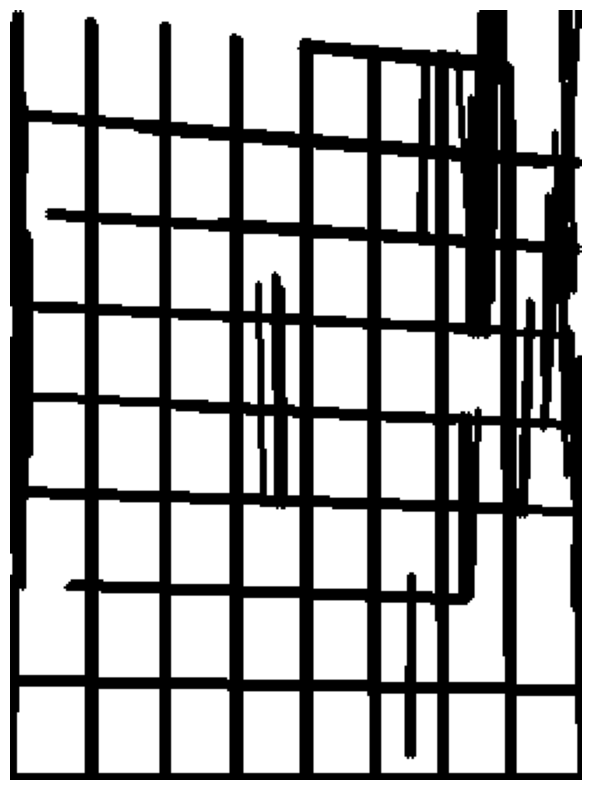

In [48]:
# Detect straight lines
dilated = cv2.dilate(chessboard, None, iterations=1)
lines = cv2.HoughLinesP(dilated, 1, np.pi / 180, threshold=100, minLineLength=75, maxLineGap=10)
lines_img = np.zeros_like(chessboard)
for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(lines_img, (x1, y1), (x2, y2), (255, 255, 255), 2)

inverted_lines_img = cv2.bitwise_not(lines_img)
show_image(inverted_lines_img)


## Find internal checkerboard squares

485.1 970.2


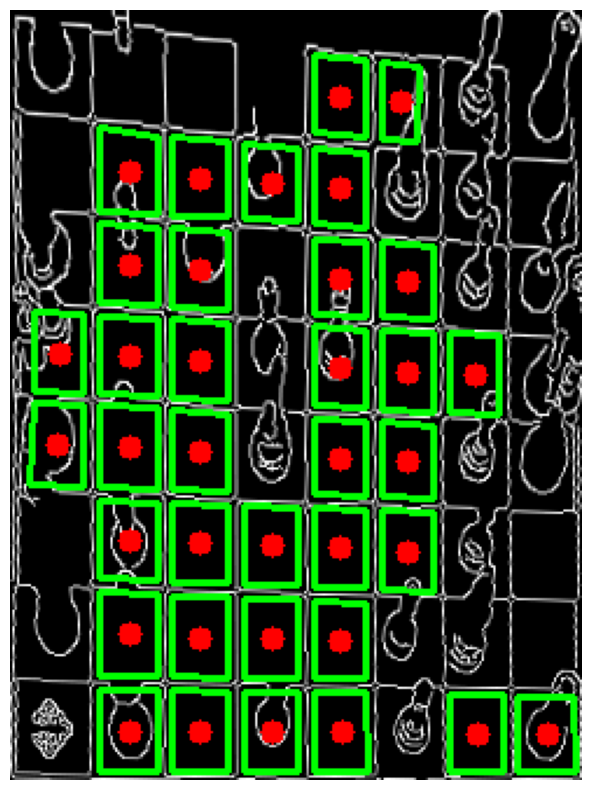

In [49]:
MIN_SQUARE_SIZE = 0.006
MAX_SQUARE_SIZE = 0.012

# Find internal checkerboard squares
board_squares = cv2.cvtColor(chessboard.copy(), cv2.COLOR_GRAY2BGR)  
board_contours, hierarchy = cv2.findContours(inverted_lines_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
img_area = inverted_lines_img.shape[0] * inverted_lines_img.shape[1]
print(img_area * MIN_SQUARE_SIZE, img_area * MAX_SQUARE_SIZE)
square_centers = []
for contour in board_contours:
    if (img_area * MIN_SQUARE_SIZE) < cv2.contourArea(contour) < (img_area * MAX_SQUARE_SIZE):
        
        # Approximate the contour to a polygon
        epsilon = POLY_EPISILON_RATIO * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)

        # Ensure polygon is a square
        if len(approx) == 4:
            x, y, w, h = cv2.boundingRect(contour)
            center_x = int((x + (x + w)) / 2)
            center_y = int((y + (y + h)) / 2)
            square_centers.append([center_x,center_y])

            # Draw the contour and center point
            cv2.drawContours(board_squares, [approx], -1, (0, 255, 0), 2)
            cv2.circle(board_squares, (center_x, center_y), 5, (0, 0, 255), -1)

show_image(board_squares)

## Group squares into rows and columns

In [50]:
# Group into rows 
y_sorted = sorted(square_centers, key=lambda y: y[1])
board_rows = []
current_row = [y_sorted[0]]
for coord in y_sorted[1:]:
    if abs(coord[1] - current_row[-1][1]) < 10:  # Adjusted threshold for grouping
        current_row.append(coord)
    else:
        board_rows.append(current_row)
        current_row = [coord]
board_rows.append(current_row)

# Sort columns within each row
for i in range(len(board_rows)):
    board_rows[i] = sorted(board_rows[i], key=lambda x: x[0])
    print("Row:", board_rows[i])

Row: [[141, 37], [167, 39]]
Row: [[51, 69], [81, 72], [112, 74], [141, 76]]
Row: [[51, 109], [81, 111], [141, 115], [170, 116]]
Row: [[21, 147], [51, 148], [81, 150], [141, 153], [170, 155], [199, 156]]
Row: [[20, 186], [51, 187], [81, 189], [141, 192], [170, 193]]
Row: [[51, 227], [81, 228], [112, 229], [141, 230], [170, 232]]
Row: [[51, 267], [81, 269], [112, 269], [141, 270]]
Row: [[51, 309], [81, 309], [112, 309], [142, 309], [200, 310], [230, 310]]


## Fill missing squares

Row 0 has 2 squares, filling missing squares...
    Inserted missing square at the end: [196, 38]
    Inserted missing square at the end: [225, 38]
    Inserted missing square at the start: [112, 38]
    Inserted missing square at the start: [83, 38]
    Inserted missing square at the start: [54, 38]
    Inserted missing square at the start: [25, 38]
Row 1 has 4 squares, filling missing squares...
    Inserted missing square at the end: [170, 72]
    Inserted missing square at the end: [199, 72]
    Inserted missing square at the end: [228, 72]
    Inserted missing square at the start: [22, 72]
Row 2 has 4 squares, filling missing squares...
    Inserted missing square at the end: [199, 112]
    Inserted missing square at the end: [228, 112]
    Inserted missing square at the start: [22, 112]
    Inserted missing square at index 3: [110, 112]
Row 3 has 6 squares, filling missing squares...
    Inserted missing square at the end: [228, 151]
    Inserted missing square at index 3: [110, 

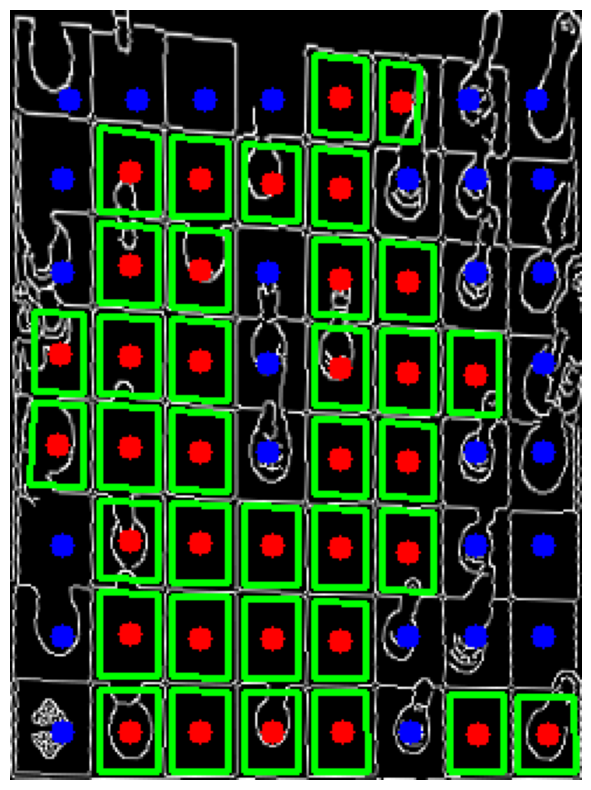

In [51]:
CHECKERBOARD_SIZE = 8

# Find the average of the minimum x-difference between squares in the rows
avg_x = 0
valid_rows = 0
for row in board_rows:
    if len(row) > 2:
        min_x_diff = min(abs(row[j][0] - row[j + 1][0]) for j in range(len(row) - 1))
        avg_x += min_x_diff
        valid_rows += 1
avg_x = avg_x // valid_rows

# Fill missing squares
for r in range(len(board_rows)):
    if len(board_rows[r]) < CHECKERBOARD_SIZE:
        print(f"Row {r} has {len(board_rows[r])} squares, filling missing squares...")
        row = board_rows[r]

        # Find the average y-coordinate of the row
        avg_y = int(sum(coord[1] for coord in row) / len(row))

        # Check if its missing squares at the end of the row
        max_last_x = max(row[-1][0] for row in board_rows)
        last_square_diff = abs(row[-1][0] - max_last_x)
        while (last_square_diff > avg_x * 0.5) and len(board_rows[r]) < CHECKERBOARD_SIZE: 
            new_square = [row[-1][0] + avg_x, avg_y]
            board_rows[r].append(new_square)
            print(f"    Inserted missing square at the end: {new_square}")
            cv2.circle(board_squares, (new_square[0], new_square[1]), 5, (255, 0, 0), -1)
            last_square_diff = abs(board_rows[r][-1][0] - max_last_x)

        # Check if its missing squares at the start of the row
        min_first_x = min(row[0][0] for row in board_rows)
        first_square_diff = abs(row[0][0] - min_first_x)
        while (first_square_diff > avg_x * 0.5) and len(board_rows[r]) < CHECKERBOARD_SIZE: 
            new_square = [row[0][0] - avg_x, avg_y]
            board_rows[r].insert(0, new_square)
            print(f"    Inserted missing square at the start: {new_square}")
            cv2.circle(board_squares, (new_square[0], new_square[1]), 5, (255, 0, 0), -1)
            first_square_diff = abs(board_rows[r][0][0] - min_first_x)
            
        # Check if its missing squares at the middle of the row
        while len(board_rows[r]) < CHECKERBOARD_SIZE:
            row = board_rows[r]
            for i in range(1, len(row)): 
                col_diff = row[i][0] - row[i - 1][0]
                if abs(col_diff) > avg_x * 1.5: 
                    new_square = [row[i - 1][0] + avg_x, avg_y]
                    board_rows[r].insert(i, new_square)
                    print(f"    Inserted missing square at index {i}: {new_square}")
                    cv2.circle(board_squares, (new_square[0], new_square[1]), 5, (255, 0, 0), -1)
                    break # Run check again, taking new square into consideration 

show_image(board_squares)

## Assing each piece to a board square

Piece squares: [['white-bishop', 'c1', (80, 98)], ['white-king', 'e1', (71, 170)], ['black-pawn', 'b7', (276, 70)], ['white-rook', 'a1', (86, 33)], ['black-bishop', 'c8', (312, 100)], ['black-king', 'e8', (328, 172)], ['black-queen', 'd8', (325, 140)], ['black-pawn', 'g6', (256, 267)], ['white-knight', 'g1', (68, 264)], ['white-pawn', 'b4', (178, 68)], ['black-knight', 'e4', (183, 177)], ['white-queen', 'd1', (78, 133)], ['white-pawn', 'h4', (186, 316)], ['white-rook', 'h2', (105, 322)], ['white-pawn', 'f2', (110, 223)], ['black-pawn', 'a7', (273, 35)], ['white-pawn', 'e2', (114, 179)], ['white-pawn', 'c2', (117, 102)], ['white-pawn', 'a2', (118, 34)], ['black-bishop', 'g7', (294, 269)], ['black-pawn', 'e7', (289, 177)], ['black-knight', 'b6', (245, 68)], ['white-pawn', 'd4', (181, 134)], ['white-bishop', 'f1', (66, 216)], ['black-pawn', 'd5', (214, 135)], ['white-knight', 'c3', (151, 96)], ['black-pawn', 'f7', (293, 220)], ['black-pawn', 'h6', (267, 318)], ['black-pawn', 'c7', (280, 1

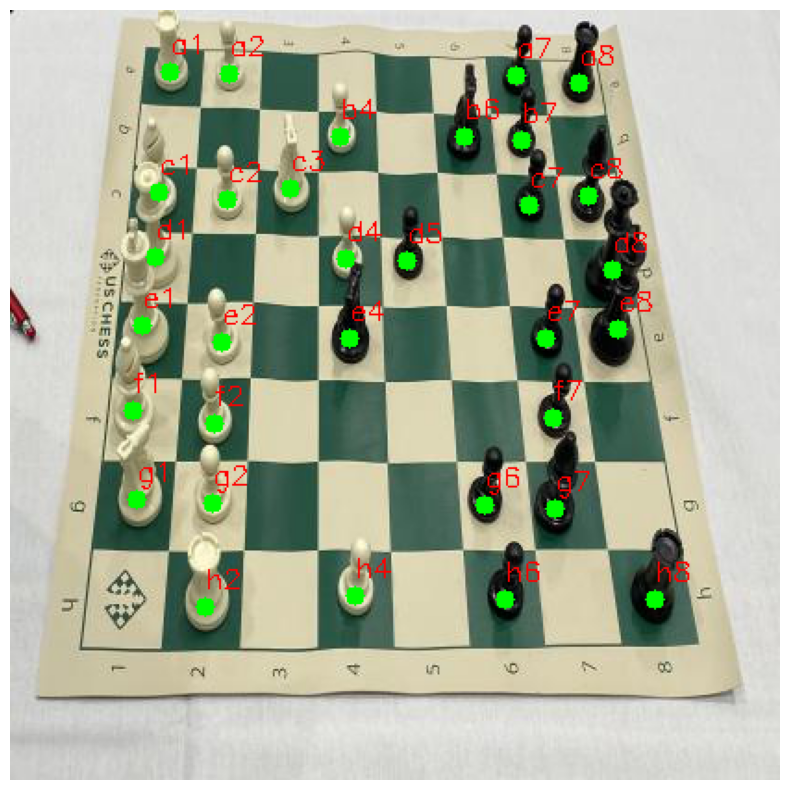

In [52]:
ROWS_ORDER = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
COLUMNS_ORDER = ['1', '2', '3', '4', '5', '6', '7', '8']

# Asign a square to each detected piece
piece_squares = []
for piece, (cx, cy) in detected_pieces:
    closest_square = None
    for r, row in enumerate(board_rows):
        for c, square in enumerate(row):
            
            # Tranform coordinates of the piece to the new perspective
            transformed_c = cv2.perspectiveTransform(np.array([[[cx, cy]]], dtype=np.float32), transformation_matrix)
            new_cx, new_cy = transformed_c[0][0]

            # Find closest dist
            dist = np.sqrt((new_cx - square[0]) ** 2 + (new_cy - square[1]) ** 2)
            if closest_square is None or dist < closest_square[0]:
                closest_square = (dist, r, c)

    if closest_square:
        dist, r, c = closest_square
        square_string = f"{ROWS_ORDER[r]}{COLUMNS_ORDER[c]}"
        piece_squares.append([piece, square_string, (cx, cy)])

# Draw square for each piece
print("Piece squares:", piece_squares)
annotated_img = image.copy()
for _, square_string, (cx, cy) in piece_squares:
    cv2.circle(annotated_img, (cx, cy), 5, (0, 255, 0), -1)
    cv2.putText(annotated_img, square_string, (cx, cy - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
show_image(annotated_img)

## Stochfish inference

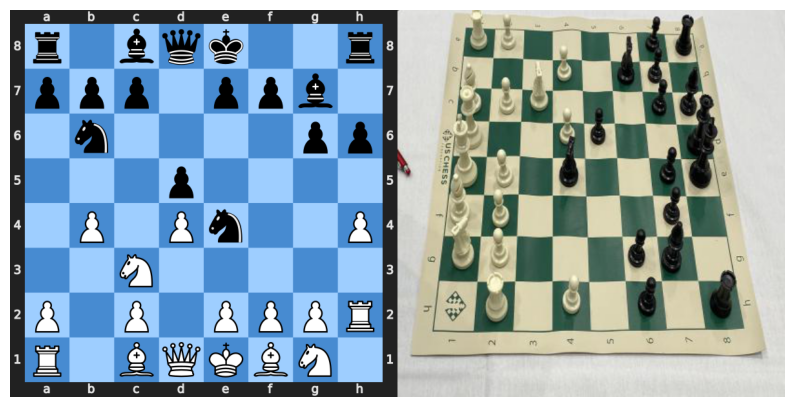

Board position:
r1bqk2r/ppp1ppb1/1n4pp/3p4/1P1Pn2P/2N5/P1P1PPPR/R1BQKBN1 b - - 0 1
Best move (White to play): c3e4
Best move (Black to play): e4c3


In [53]:
board = chess.Board(None) 

# Place pieces in the board
piece_map = {'pawn': 'P', 'knight': 'N', 'bishop': 'B', 'rook': 'R', 'queen': 'Q', 'king': 'K'}
for piece_name, square_str, _ in piece_squares:
    color, name = piece_name.split('-')
    symbol = piece_map[name].upper() if color == 'white' else piece_map[name].lower()
    square = chess.parse_square(square_str)
    board.set_piece_at(square, chess.Piece.from_symbol(symbol))

# Convert to svg and display
svg_data = chess.svg.board(board=board, size=600)
png_bytes = cairosvg.svg2png(bytestring=svg_data)
img_array = np.frombuffer(png_bytes, dtype=np.uint8)
board_img = cv2.imdecode(img_array, cv2.IMREAD_UNCHANGED)
board_img = cv2.cvtColor(board_img, cv2.COLOR_RGBA2BGR)
side_by_side = np.hstack([board_img, cv2.resize(image, (board_img.shape[0], board_img.shape[1]))])
show_image(side_by_side)

# Evaluate best move with stockfish
sf = Stockfish(STOCKFISH_PATH)

sf.set_fen_position(board.fen())
best_move_white = sf.get_best_move()

board.turn = chess.BLACK
sf.set_fen_position(board.fen())
best_move_black = sf.get_best_move()

print("Board position:")
print(board.fen())
print(f"Best move (White to play): {best_move_white}")
print(f"Best move (Black to play): {best_move_black}")